
## 🎯 Optimization Objectives

We will:

- Analyze the class imbalance
- Establish baseline performance
- Experiment with class-weighted models
- Evaluate SMOTE-based resampling
- Perform hyperparameter tuning
- Optimize the classification threshold
- Compare optimized models
- Select the final model for deployment

In [1]:
import pandas as pd
import numpy as np

# ==========================================================
# Machine Learning Models
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ==========================================================
# Model Selection & Optimization
# ==========================================================

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV
)

# ==========================================================
# Evaluation Metrics
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

# ==========================================================
# Imbalanced Learning
# ==========================================================

from imblearn.over_sampling import SMOTE

# ==========================================================
# Visualization
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# Utilities
# ==========================================================

import warnings
import joblib
import os

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

### Load Processed Datasets

In [2]:
X_train  = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (204277, 24)
X_test : (51070, 24)
y_train: (204277,)
y_test : (51070,)


# Analyze Class Distribution
The training data contains significantly more non-default cases than
default cases.

This imbalance can cause a model to favor the majority class.

In [3]:
class_distribution = pd.DataFrame({
    "Count": y_train.value_counts(),
    "Percentage": y_train.value_counts(normalize=True) * 100
})

class_distribution

,Count,Percentage
Default,,
0,180555,88.387337
1,23722,11.612663


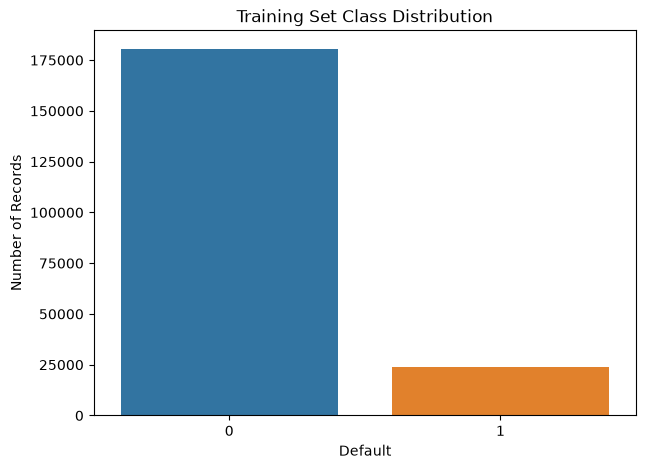

In [4]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train,
    hue=y_train,
    legend=False
)

plt.title("Training Set Class Distribution")
plt.xlabel("Default")
plt.ylabel("Number of Records")

plt.show()

## Outcome of this

The training dataset is imbalanced with "Default = 0" representing the majority class and "Default = 1" representing the minority class


In [5]:
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.8852,
        0.8014,
        0.8853,
        0.8865
    ],
    "Precision": [
        0.6024,
        0.1958,
        0.6437,
        0.5928
    ],
    "Recall": [
        0.0332,
        0.2285,
        0.0283,
        0.0727
    ],
    "F1 Score": [
        0.0630,
        0.2108,
        0.0543,
        0.1295
    ],
    "ROC-AUC": [
        0.7531,
        0.5526,
        0.7412,
        0.7544
    ]
})

baseline_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8852,0.6024,0.0332,0.0630,0.7531
1,Decision Tree,0.8014,0.1958,0.2285,0.2108,0.5526
2,Random Forest,0.8853,0.6437,0.0283,0.0543,0.7412
3,XGBoost,0.8865,0.5928,0.0727,0.1295,0.7544


# Class Weighted models

Instead of changing the dataset itself, class weighting changes the cost
associated with misclassifying different classes.

We will test class weighting on:

- Logistic Regression
- Decision Tree
- Random Forest

XGBoost will be handled separately using its `scale_pos_weight` parameter.



# Calculate Class Weight Ratio

For Binary classification, Imbalance ratio is estimated using : 
    Number of majority-class samples
    --------------------------------
    Number of minority-class samples

This value will provides an initial weihting strategy for XGboost


In [6]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative Class:", negative_count)
print("Positive Class:", positive_count)
print("Scale Positive Weight:", round(scale_pos_weight, 2))

Negative Class: 180555
Positive Class: 23722
Scale Positive Weight: 7.61


## Interpretation

The calculated ratio indicates how much more frequently the majority class
appears compared with the minority class.

This ratio will be used as an initial class-weighting strategy rather than
being treated as a guaranteed optimal value.

### Class-Weighted Decision Tree

With balanced class weights

In [7]:
weighted_dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

weighted_dt.fit(X_train, y_train)

dt_pred = weighted_dt.predict(X_test)
dt_prob = weighted_dt.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC-AUC  :", roc_auc_score(y_test, dt_prob))

Accuracy : 0.815273154493832
Precision: 0.20378826314899373
Recall   : 0.20316978587084808
F1 Score : 0.20347855454238434
ROC-AUC  : 0.5494348674585636


### Class-Weighted Random Forest
Trained with balanced class weights to increase the importance of minority-class observations.

In [8]:
weighted_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

weighted_rf.fit(X_train, y_train)

rf_pred = weighted_rf.predict(X_test)
rf_prob = weighted_rf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.880634423340513
Precision: 0.45709828393135726
Recall   : 0.14820435002529084
F1 Score : 0.2238349885408709
ROC-AUC  : 0.7472354460486652


### Class-weighted Logistic Regression

Trained with balanced class weights to increase the importance of minority-class observations.

In [9]:
weighted_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

weighted_lr.fit(X_train, y_train)

lr_pred = weighted_lr.predict(X_test)
lr_prob = weighted_lr.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lr_prob))

Accuracy : 0.6763266105345604
Precision: 0.21955866010477854
Recall   : 0.6995447647951442
F1 Score : 0.3342194296761721
ROC-AUC  : 0.7531804240610736


### Class-Weighted XGBoost

XGBoost handles class imbalance using the `scale_pos_weight` parameter.

The calculated class ratio will be used as an initial value.

In [10]:
weighted_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

weighted_xgb.fit(X_train, y_train)

xgb_pred = weighted_xgb.predict(X_test)
xgb_prob = weighted_xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

Accuracy : 0.7128451145486587
Precision: 0.23446430743037822
Recall   : 0.6501433147867138
F1 Score : 0.34463958528846583
ROC-AUC  : 0.7528113921691796


In [11]:
# SUMMARY OF RESULTS

# XG boost : 
# Recall(Before) : 0.0727 --> 7.27%
# Recall(After)  : 0.6501 --> 65.01%

# That's a massive improvement in recall

## Create Validation Set

The original training data will be divided into :

- Training Set
- Validation Set → Used for model and threshold        optimization
- Test Set

(the test set will not be used during threshold selection of hyparameter optimization)

